In [42]:
import jones_tensor
import numpy as np
import matplotlib.pyplot as plt
import cotengra
import torch

This example shows how to use `cotengra` to find better contraction paths for very large links.

NB: For the best results, it is important that `cotengra`s optional dependencies are installed, for example `kahypar`.

We start by constructing a very large torus knot with 323 crossings, along with the point $q$ that we want to evaluate:

In [79]:
torus_18_19 = jones_tensor.MorseLink.from_braid(list(range(1, 18))*19)
q = np.exp(1j * 1.5)

Then we can define a `cotengra.HyperOptimizer` to do the pathfinding. See [the cotengra docs](https://cotengra.readthedocs.io/en/latest/basics.html#quick-start) for more information about the options available.

In [95]:
opt = cotengra.ReusableHyperOptimizer(
    methods = ['kahypar', 'random-greedy'],
    minimize = 'combo',
    max_repeats = 256,
    progbar = True,
    parallel = True
)

We could pass this straight to `evaluate_jones` but let's construct the tensor network explicitly so that we can inspect it:

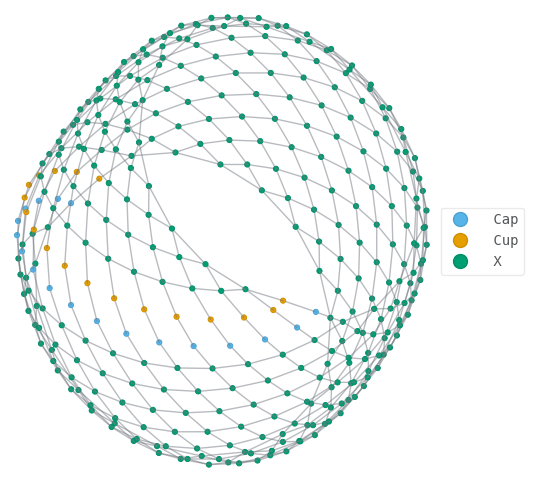

In [83]:
net, _ = jones_tensor.construct_network(q, torus_18_19)
net.draw(color=['Cap', 'Cup', 'X'], show_tags=False, dim=3)

Now we will call the optimizer to find a contraction path - we will get only the contraction tree here to inspect it:

In [96]:
tree = net.contract(optimize=opt, get='tree')

F=14.03 C=14.04 S=36.00 P=36.02: 100%|██████████| 256/256 [00:18<00:00, 13.50it/s] 


Unfortunately we can see that this will take too much memory to fit on the GPU:

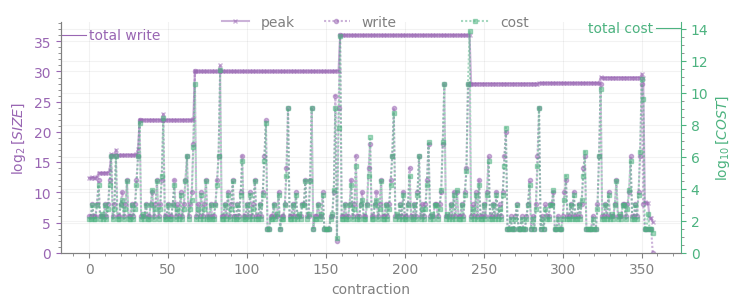

In [97]:
tree.plot_contractions();

So let's try instructing the optimizer to use slicing, which will decrease memory consumption, but may increase the time required.

(NB: The outputs recorded here were obtained with a NVIDIA 2080 Super, with 8GB VRAM. If you have a bigger GPU, you may be able to speed things up by increasing the memory cap.)

In [86]:
opt = cotengra.ReusableHyperOptimizer(
    methods = ['kahypar', 'random-greedy'],
    minimize = 'combo',
    max_repeats = 256,
    progbar = True,
    parallel = True,
    slicing_reconf_opts={"target_size": 2**26}
)
tree = net.contract(optimize=opt, get='tree')

F=13.47 C=13.72 S=26.00 P=27.00 $=1024.00: 100%|██████████| 256/256 [01:00<00:00,  4.24it/s]


Indeed, memory consumption has been greatly reduced:

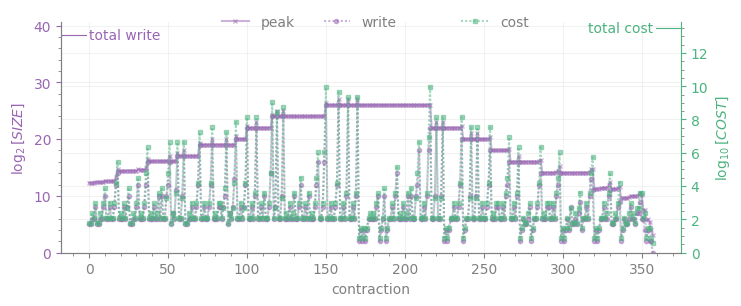

In [90]:
tree.plot_contractions();

Now we can do the actual computation (the contraction tree has been cached from earlier):

In [93]:
with torch.device('cuda'):
    jones = jones_tensor.evaluate_jones(q, torus_18_19, optimize=opt, backend='torch')
jones

(-1.090456204192595-0.4383573536777732j)